In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [39]:
import pygad
import numpy as np
import torch
import os
from ga.fitness import constrained_fitness_func
from ga.mutation import random_float_mutation, custom_mutation
from ga.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config, pixel_cleaning_operation

In [40]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [87]:
config = load_config()

In [42]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [43]:
model = load_model(config["model"]["model_type"], device=device)

Using device: mps


# Loading

In [44]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [88]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [89]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config

In [90]:
def fitness_wrapper(ga_instance, solution, solution_idx):
    return constrained_fitness_func(
        ga_instance, solution, solution_idx, model, input_batch, labels, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    )

In [91]:
def mutation_wrapper(offspring, ga_instance):

    return random_float_mutation(offspring, ga_instance)
    # return custom_mutation(offspring, ga_instance, pixel_std, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], input_batch, apply_pixel_constraints=False)

In [100]:
def on_crossover(ga_instance, offspring):
    # print("Number of zeros before pixel cleaning in crossover:", torch.sum(torch.tensor(offspring == 0)))
    offspring = pixel_cleaning_operation(offspring, cleaning_probability=0.2)
    return offspring

In [101]:
def on_generation(ga_instance):

    print(f"\nGeneration {ga_instance.generations_completed} completed with fitness: {ga_instance.last_generation_fitness}")

    print(f"Input batch starting label: {labels[0]}")

    # input_batch, labels = next(iter(dataloader))
    # input_batch, labels = input_batch.to(device), labels.to(device)
    # print(f"New batch loaded with first label: {labels[0]}")
    
    # Print the best fitness for this generation
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()
    print(f"Best Fitness = {best_solution_fitness}\n")
    num_zeros_best = np.count_nonzero(np.isclose(best_solution, 0.0))
    print(f"Best solution zeros count after pixel cleaning: {num_zeros_best}")

    # # Print out samples from the top 3 perturbations
    # top_fitness = sorted(ga_instance.last_generation_fitness)[-3:]
    # for i, perturbation in enumerate(top_fitness):
    #     print(f"Top {i+1} perturbation: {torch.norm(perturbation).item()}")

    best_perturbation = torch.tensor(best_solution).float().reshape(input_batch.shape[1:])
    top_perturbations.append(best_perturbation)
    print(f"Best perturbation magnitude: {torch.norm(best_perturbation).item()}")

    ########
    # VISUALIZATION
    ########
    if config["visualization"]["visualize"] and ga_instance.generations_completed % config["visualization"]["visualize_every"] == 0:
        print(f"Visualizing")
        # get the current best perturbation
        visualize_images_batch(input_batch, best_perturbation)

    # print(f"Generation {ga_instance.generations_completed}: Current Fitness: Best Fitness = {ga_instance.best_solution()[1]}")


Generation 1 completed with fitness: [-1.76259918 -0.86180878 -0.80007477 -0.80338287 -0.84799347 -0.79067078
 -0.81148071 -0.84675903 -0.75605316 -0.82989502 -0.77768555 -0.80554352
 -0.77204895 -0.84554443 -0.86427917 -0.82604675 -0.76728516 -0.89231873
 -0.76579437 -0.76730652]
Input batch starting label: 239
Best Fitness = -0.7560531616210939

Best solution zeros count after pixel cleaning: 21192
Best perturbation magnitude: 207.09169006347656

Generation 2 completed with fitness: [-0.75605316 -0.46764832 -0.45665741 -0.49719086 -0.3789566  -0.44771576
 -0.48257904 -0.43916931 -0.43485413 -0.48184662 -0.38432465 -0.44175262
 -0.47399445 -0.4697525  -0.48365173 -0.46284332 -0.45087433 -0.43703766
 -0.48783569 -0.41996765]
Input batch starting label: 239
Best Fitness = -0.3789566040039063

Best solution zeros count after pixel cleaning: 33017
Best perturbation magnitude: 197.07073974609375

Generation 3 completed with fitness: [-0.3789566  -0.53104706 -0.4819931  -0.54287872 -0.5174

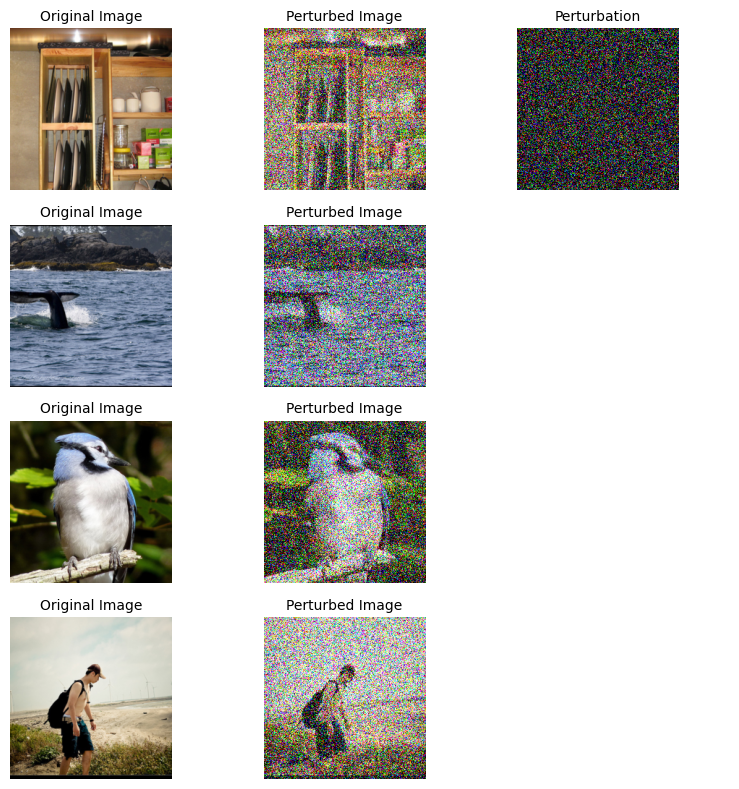


Generation 5 completed with fitness: [-0.3789566  -1.19393616 -1.27549896 -1.33523102 -1.29039154 -1.27565002
 -1.25815125 -1.21955872 -1.32241211 -1.30744781 -1.19699097 -1.53798218
 -1.27505493 -1.27655182 -1.33460388 -1.23638763 -1.32829895 -1.32741089
 -1.24557037 -1.27958374]
Input batch starting label: 239
Best Fitness = -0.3789566040039063

Best solution zeros count after pixel cleaning: 33017
Best perturbation magnitude: 197.07073974609375

Generation 6 completed with fitness: [-0.3789566  -1.78848419 -2.08299866 -2.04275208 -2.04217224 -1.84611511
 -1.75680542 -1.79382172 -1.73886261 -1.83229218 -2.13110657 -1.79926758
 -2.04879456 -1.74382477 -1.90511475 -1.80809784 -2.12508087 -2.0697876
 -1.75436096 -1.82724915]
Input batch starting label: 239
Best Fitness = -0.3789566040039063

Best solution zeros count after pixel cleaning: 33017
Best perturbation magnitude: 197.07073974609375

Generation 7 completed with fitness: [-0.3789566  -2.26550598 -2.36577301 -2.43368683 -2.49782

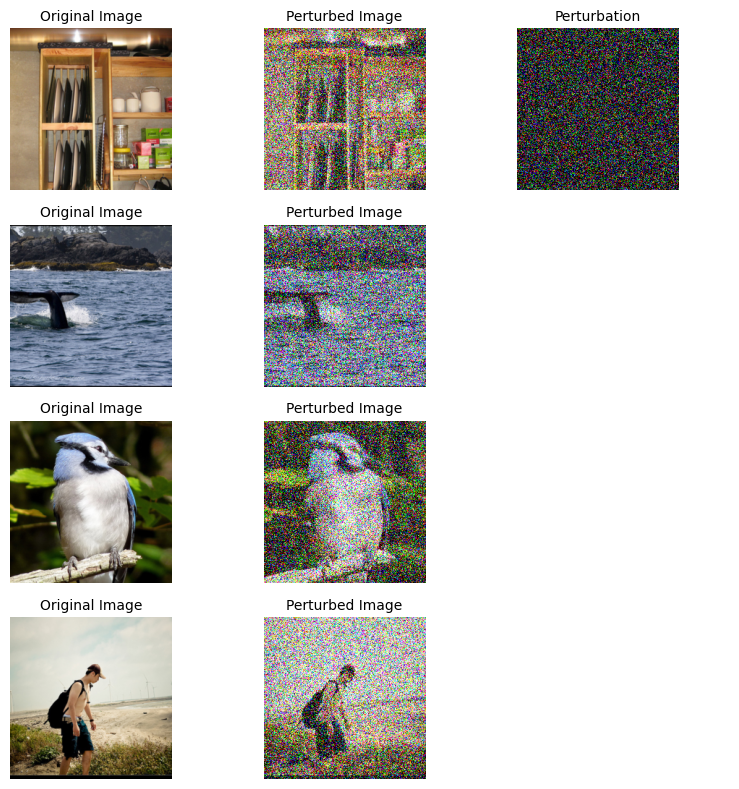

In [107]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    crossover_type=config["ga"]["crossover_type"],
    crossover_probability=config["ga"]["crossover_probability"],
    mutation_type=mutation_wrapper,
    mutation_probability=config["ga"]["mutation_probability"],
    mutation_percent_genes=config["ga"]["mutation_percent_genes"],
    fitness_func=fitness_wrapper,
    on_generation=on_generation,
    on_crossover=on_crossover,
)

ga_instance.run()

##### Best fitness records
- no pixel constraints: 0.84
- pixel constraint weight 1: 0.80
- above + max perturbation mag 100: 

In [ ]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [19]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.828125


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


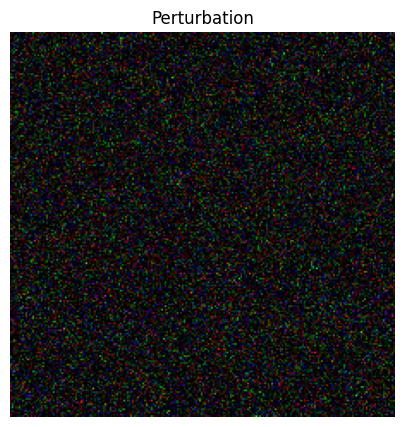

In [32]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

# Metrics

### GoogLeNet

In [22]:
evaluate_without_perturbation(model, dataloader)

Accuracy without perturbation: 0.69772


0.69772

In [23]:
evaluate_with_perturbation(model, dataloader, universal_perturbation)

Accuracy with perturbation: 0.37964


0.37964

### ViT b 16

In [33]:
evaluate_without_perturbation(model, dataloader)
evaluate_with_perturbation(model, dataloader, universal_perturbation)

Accuracy without perturbation: 0.69772


KeyboardInterrupt: 